## Let's go through some code to discuss dropout and changing weights/layers

Start with no modifications using SGD on spiral dataset

epoch: 1, acc: 40.000, loss: 1.099, lr: 1.0


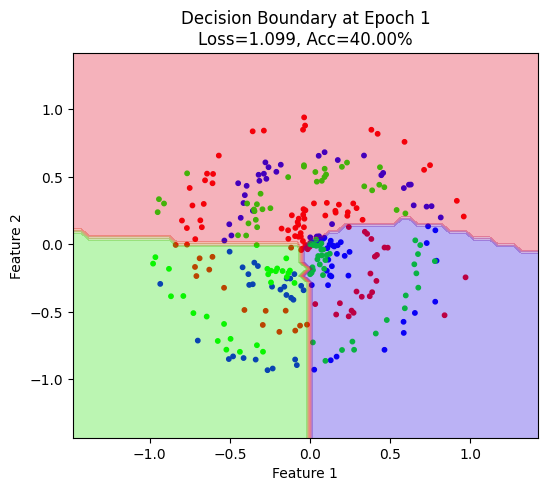

epoch: 10000, acc: 89.667, loss: 0.252, lr: 0.09091735612328393


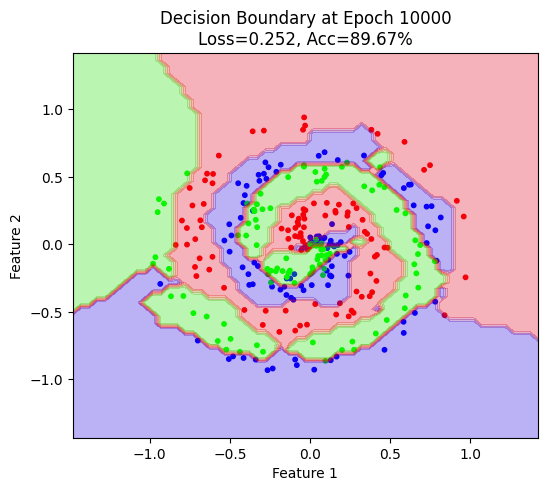

validation, acc: 0.803, loss: 0.637


In [1]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


nnfs.init()


# Dense layer
class Layer_Dense:
    # Layer Initialization
    def __init__(self, n_inputs, n_neurons):
        # Initialize weights and biases
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    # Forward Pass
    def forward(self, inputs):
        # Remember input values
        self.inputs = inputs
        # Calculate output values from inputs, weights and biases
        self.output = np.dot(inputs, self.weights) + self.biases
    
    # Backward Pass
    def backward(self, dvalues):
        # Gradients on parameters
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        # Gradient on values
        self.dinputs = np.dot(dvalues, self.weights.T)


# ReLU activation
class Activation_ReLU:
    
    # Forward pass
    def forward(self, inputs):
        # Remember input values
        self.inputs = inputs
        # Calculate output values from input
        self.output = np.maximum(0, inputs)
    
    # Backward pass
    def backward(self, dvalues):
        # Since we need to modify the original variable,
        # let's make a copy of the values first
        self.dinputs = dvalues.copy()

        # Zero gradient where input values were negative
        self.dinputs[self.inputs <= 0] = 0


# Softmax activation
class Activation_Softmax:
    # Forward pass
    def forward(self, inputs):
        # Remember input values
        self.inputs = inputs

        # Get unnormalized probabilities
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))

        # Normalize them for each sample
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)

        self.output = probabilities
    
    # Backward pass
    def backward(self, dvalues):
        # Create uninitialized array
        self.dinputs = np.empty_like(dvalues)

        # Enumerate outputs and gradients
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)):
            # Flatten output array
            single_output = single_output.reshape(-1, 1)
            # Calculate Jacobian matrix of the output
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T)

            # Calculate sample-wise gradient
            # and add it to the array of sample gradients
            self.dinputs[index] = np.dot(jacobian_matrix, single_dvalues)


# Common loss class
class Loss:
    # Calculates the data and regularization losses
    # given model output and ground truth values
    def calculate(self, output, y):

        # Calculate sample losses
        sample_losses = self.forward(output, y)

        # Calculate mean loss
        data_loss = np.mean(sample_losses)

        # Return loss
        return data_loss


# Cross-entropy loss
class Loss_CategoricalCrossentropy(Loss):
    # Forward pass
    def forward(self, y_pred, y_true):

        # Number of samples in a batch
        samples = len(y_pred)

        # Clip data to prevent division by 0
        # Clip both sides to not drag mean towards any value
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)

        # Probabilities for target values - only if categorical labels
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(samples),
                y_true
            ]
        # Mask values - only for one-hot encoded labels
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped * y_true,
                axis=1
            )
        
        # Losses
        negative_log_likelihoods = -np.log(correct_confidences)

        return negative_log_likelihoods

    # Backward pass
    def backward(self, dvalues, y_true):

        # Number of samples
        samples = len(dvalues)
        # Number of labels in every sample
        # We'll use the first sample to count them
        labels = len(dvalues[0])

        # If labels are sparse, turn them into one-hot vector
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
        
        # Calculate the gradient
        self.dinputs = -y_true / dvalues
        # Normalize gradient
        self.dinputs = self.dinputs / samples


# Softmax classifier - combined Softmax activation
# and cross-entropy loss for faster backward step
class Activation_Softmax_Loss_CategoricalCrossentropy():

    # Creates activation and loss function objects
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossentropy()
    
    # Forward pass
    def forward(self, inputs, y_true):
        # Output layer's activation function
        self.activation.forward(inputs)
        # Set the output
        self.output = self.activation.output
        # Calculate and return loss value
        return self.loss.calculate(self.output, y_true)
    
    # Backward pass
    def backward(self, dvalues, y_true):
        
        # Number of samples
        samples = len(dvalues)
        # If labels are one-hot encoded, 
        # turn them into discrete values
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
        
        # Copy so we can safely modify
        self.dinputs = dvalues.copy()
        # Calculate gradient
        self.dinputs[range(samples), y_true] -= 1
        # Normalize gradient
        self.dinputs = self.dinputs / samples


# SGD (Stochastic Gradient Descent) Optimizer
class Optimizer_SGD:
    # Initialize optimizer - set settings,
    # learning rate of 1. is the default for this optimizer
    def __init__(self, learning_rate=1., decay=0., momentum=0.):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.momentum = momentum
    
    # Call once before any parameter updates
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations))

    # Update parameters
    def update_params(self, layer):
        
        # If we use momentum
        if self.momentum:

            # If layer does not contain momentum arrays, create them 
            # filled with zeros
            if not hasattr(layer, "weight_momentums"):
                layer.weight_momentums = np.zeros_like(layer.weights)
                # If there is no momentum array for weights
                # The array doesn't exist for biases yet either.
                layer.bias_momentums = np.zeros_like(layer.biases)
            
            # Build weight updates with momentum - take previous
            # updates multiplied by retain factor and update with
            # current gradients
            weight_updates = (self.momentum * layer.weight_momentums) - (self.current_learning_rate * layer.dweights)
            layer.weight_momentums = weight_updates

            # Build bias updates
            bias_updates = (self.momentum * layer.bias_momentums) - (self.current_learning_rate * layer.dbiases)
            layer.bias_momentums = bias_updates
        # Vanilla SGD updates (as before momentum update)
        else:
            weight_updates = -self.current_learning_rate * layer.dweights
            bias_updates = -self.current_learning_rate * layer.dbiases

        # Update weights and biases using either
        # vanilla or momentum updates
        layer.weights += weight_updates
        layer.biases += bias_updates
    
    # Call once after any parameter updates
    def post_update_params(self):
        self.iterations += 1


# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 64 output values
dense1 = Layer_Dense(2, 64)

# Create ReLU activation (to be used with Dense layer):
activation1 = Activation_ReLU()

# Create second Dense layer with 64 input features (as we take output
# of the previous layer here) and 3 output values
dense2 = Layer_Dense(64, 3)

# Create Softmax classifier's combined loss and activation
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

# Create optimizer
# Decay options: 1e-2=0.01, 1e-3=0.001, 1e-4=0.0001, 1e-5=0.00001
optimizer = Optimizer_SGD(decay=1e-3, momentum=0.9)


CREATE_PLOT = True


# Training loop
for epoch in range(10_001):
    
    # Forward pass
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss = loss_activation.forward(dense2.output, y)
    
    # Calculate accuracy
    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y.shape) == 2:
        y = np.argmax(y, axis=1)
    accuracy = np.mean(predictions == y) * 100  # Convert to percentage
    # accuracy = np.mean(predictions == y)

    if epoch == 1 or epoch == 10000:
        print(f"epoch: {epoch}, " +
            f"acc: {accuracy:.3f}, " +
            f"loss: {loss:.3f}, " +
            f"lr: {optimizer.current_learning_rate}")

    # Backward pass
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)
    
    # Update weights and biases
    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()

    if CREATE_PLOT and (epoch == 1 or epoch == 10000):
        # Decision boundary
        plt.figure(figsize=(6, 5))
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg', s=10)

        # Create grid for decision regions
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                            np.arange(y_min, y_max, 0.05))
        grid_points = np.c_[xx.ravel(), yy.ravel()]

        # Forward pass for grid
        dense1.forward(grid_points)
        activation1.forward(dense1.output)
        dense2.forward(activation1.output)
        predictions_grid = np.argmax(dense2.output, axis=1)
        predictions_grid = predictions_grid.reshape(xx.shape)

        # Contour plot
        plt.contourf(xx, yy, predictions_grid, cmap='brg', alpha=0.3)
        plt.title(f"Decision Boundary at Epoch {epoch}\nLoss={loss:.3f}, Acc={accuracy:.2f}%")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.show()


if CREATE_PLOT:
    plt.ioff()  # Turn off interactive mode
    plt.show()  # Keep the plot open at the end


# Validate the model

# Create the test dataset
X_test, y_test = spiral_data(samples=100, classes=3)

# Perform a forward pass of our testing data through this layer
dense1.forward(X_test)

# Perform a forward pass through activation function
# takes the output of first dense layer here
activation1.forward(dense1.output)

# Perform a forward pass through second Dense layer
# takes outputs of activation function of first layer as inputs
dense2.forward(activation1.output)

# Perform a forward pass through the activation/loss function
# takes the output of second dense layer here and returns loss
loss = loss_activation.forward(dense2.output, y_test)

# Calculate accuracy from output of activation2 and targets
# calculate values along first axis
predictions = np.argmax(loss_activation.output, axis=1)
if len(y_test.shape) == 2:
    y_test = np.argmax(y_test, axis=1)
accuracy = np.mean(predictions == y_test)

print(f"validation, acc: {accuracy:.3f}, loss: {loss:.3f}")


Let's add dropout!

epoch: 1, acc: 40.000, loss: 1.098, lr: 1.0


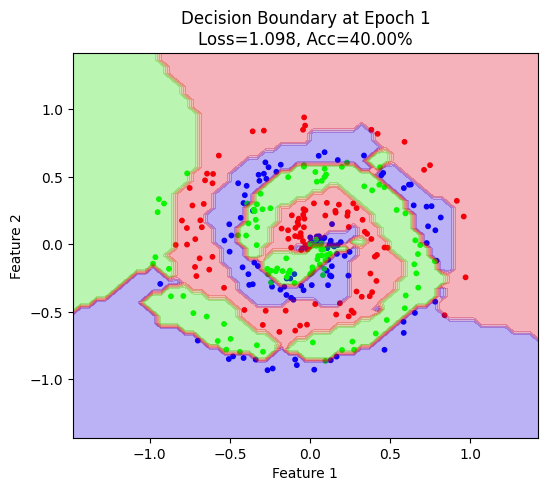

epoch: 10000, acc: 84.000, loss: 0.433, lr: 0.09091735612328393


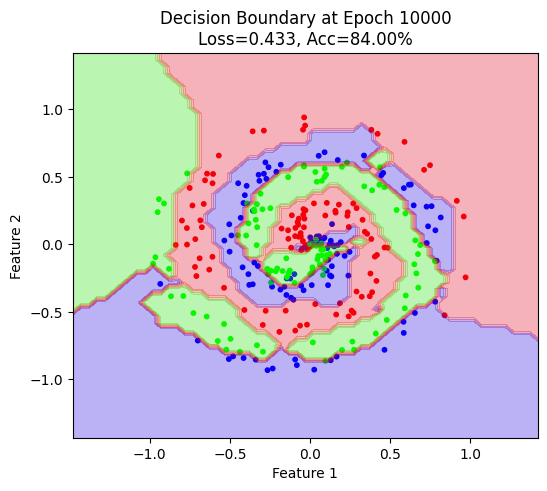

validation, acc: 0.827, loss: 0.607


In [4]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


nnfs.init()


# Dense layer
class Layer_Dense:
    # Layer Initialization
    def __init__(self, n_inputs, n_neurons):
        # Initialize weights and biases
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    # Forward Pass
    def forward(self, inputs):
        # Remember input values
        self.inputs = inputs
        # Calculate output values from inputs, weights and biases
        self.output = np.dot(inputs, self.weights) + self.biases
    
    # Backward Pass
    def backward(self, dvalues):
        # Gradients on parameters
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        # Gradient on values
        self.dinputs = np.dot(dvalues, self.weights.T)


# ReLU activation
class Activation_ReLU:
    
    # Forward pass
    def forward(self, inputs):
        # Remember input values
        self.inputs = inputs
        # Calculate output values from input
        self.output = np.maximum(0, inputs)
    
    # Backward pass
    def backward(self, dvalues):
        # Since we need to modify the original variable,
        # let's make a copy of the values first
        self.dinputs = dvalues.copy()

        # Zero gradient where input values were negative
        self.dinputs[self.inputs <= 0] = 0


# Softmax activation
class Activation_Softmax:
    # Forward pass
    def forward(self, inputs):
        # Remember input values
        self.inputs = inputs

        # Get unnormalized probabilities
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))

        # Normalize them for each sample
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)

        self.output = probabilities
    
    # Backward pass
    def backward(self, dvalues):
        # Create uninitialized array
        self.dinputs = np.empty_like(dvalues)

        # Enumerate outputs and gradients
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)):
            # Flatten output array
            single_output = single_output.reshape(-1, 1)
            # Calculate Jacobian matrix of the output
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T)

            # Calculate sample-wise gradient
            # and add it to the array of sample gradients
            self.dinputs[index] = np.dot(jacobian_matrix, single_dvalues)


# Common loss class
class Loss:
    # Calculates the data and regularization losses
    # given model output and ground truth values
    def calculate(self, output, y):

        # Calculate sample losses
        sample_losses = self.forward(output, y)

        # Calculate mean loss
        data_loss = np.mean(sample_losses)

        # Return loss
        return data_loss


# Cross-entropy loss
class Loss_CategoricalCrossentropy(Loss):
    # Forward pass
    def forward(self, y_pred, y_true):

        # Number of samples in a batch
        samples = len(y_pred)

        # Clip data to prevent division by 0
        # Clip both sides to not drag mean towards any value
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)

        # Probabilities for target values - only if categorical labels
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(samples),
                y_true
            ]
        # Mask values - only for one-hot encoded labels
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped * y_true,
                axis=1
            )
        
        # Losses
        negative_log_likelihoods = -np.log(correct_confidences)

        return negative_log_likelihoods

    # Backward pass
    def backward(self, dvalues, y_true):

        # Number of samples
        samples = len(dvalues)
        # Number of labels in every sample
        # We'll use the first sample to count them
        labels = len(dvalues[0])

        # If labels are sparse, turn them into one-hot vector
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
        
        # Calculate the gradient
        self.dinputs = -y_true / dvalues
        # Normalize gradient
        self.dinputs = self.dinputs / samples


# Softmax classifier - combined Softmax activation
# and cross-entropy loss for faster backward step
class Activation_Softmax_Loss_CategoricalCrossentropy():

    # Creates activation and loss function objects
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossentropy()
    
    # Forward pass
    def forward(self, inputs, y_true):
        # Output layer's activation function
        self.activation.forward(inputs)
        # Set the output
        self.output = self.activation.output
        # Calculate and return loss value
        return self.loss.calculate(self.output, y_true)
    
    # Backward pass
    def backward(self, dvalues, y_true):
        
        # Number of samples
        samples = len(dvalues)
        # If labels are one-hot encoded, 
        # turn them into discrete values
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
        
        # Copy so we can safely modify
        self.dinputs = dvalues.copy()
        # Calculate gradient
        self.dinputs[range(samples), y_true] -= 1
        # Normalize gradient
        self.dinputs = self.dinputs / samples


# SGD (Stochastic Gradient Descent) Optimizer
class Optimizer_SGD:
    # Initialize optimizer - set settings,
    # learning rate of 1. is the default for this optimizer
    def __init__(self, learning_rate=1., decay=0., momentum=0.):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.momentum = momentum
    
    # Call once before any parameter updates
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations))

    # Update parameters
    def update_params(self, layer):
        
        # If we use momentum
        if self.momentum:

            # If layer does not contain momentum arrays, create them 
            # filled with zeros
            if not hasattr(layer, "weight_momentums"):
                layer.weight_momentums = np.zeros_like(layer.weights)
                # If there is no momentum array for weights
                # The array doesn't exist for biases yet either.
                layer.bias_momentums = np.zeros_like(layer.biases)
            
            # Build weight updates with momentum - take previous
            # updates multiplied by retain factor and update with
            # current gradients
            weight_updates = (self.momentum * layer.weight_momentums) - (self.current_learning_rate * layer.dweights)
            layer.weight_momentums = weight_updates

            # Build bias updates
            bias_updates = (self.momentum * layer.bias_momentums) - (self.current_learning_rate * layer.dbiases)
            layer.bias_momentums = bias_updates
        # Vanilla SGD updates (as before momentum update)
        else:
            weight_updates = -self.current_learning_rate * layer.dweights
            bias_updates = -self.current_learning_rate * layer.dbiases

        # Update weights and biases using either
        # vanilla or momentum updates
        layer.weights += weight_updates
        layer.biases += bias_updates
    
    # Call once after any parameter updates
    def post_update_params(self):
        self.iterations += 1


# Dropout layer (inverted dropout)
class Layer_Dropout:
    def __init__(self, rate):
        """
        rate: probability of dropping units (e.g., 0.1 = drop 10%)
        """
        self.rate = rate

    def forward(self, inputs, training):
        self.inputs = inputs
        if training:
            # Inverted dropout mask: keep prob = 1 - rate
            keep_prob = 1 - self.rate
            self.binary_mask = (np.random.rand(*inputs.shape) < keep_prob) / keep_prob
            self.output = inputs * self.binary_mask
        else:
            # No dropout at inference
            self.output = inputs.copy()

    def backward(self, dvalues):
        # Gradient passes only through the kept units
        self.dinputs = dvalues * self.binary_mask



# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 64 output values
dense1 = Layer_Dense(2, 200)

# Create ReLU activation (to be used with Dense layer):
activation1 = Activation_ReLU()
dropout1 = Layer_Dropout(rate=0.2)  # try 0.1–0.5; 0.2 is a good starting point


# Create second Dense layer with 64 input features (as we take output
# of the previous layer here) and 3 output values
dense2 = Layer_Dense(200, 3)

# Create Softmax classifier's combined loss and activation
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

# Create optimizer
# Decay options: 1e-2=0.01, 1e-3=0.001, 1e-4=0.0001, 1e-5=0.00001
optimizer = Optimizer_SGD(decay=1e-3, momentum=0.9)


CREATE_PLOT = True


# Training loop
for epoch in range(10_001):
    
    # Forward pass
    dense1.forward(X)
    activation1.forward(dense1.output)

    # NEW: apply dropout only during training
    dropout1.forward(activation1.output, training=True) 

    dense2.forward(dropout1.output)
    loss = loss_activation.forward(dense2.output, y)
    
    # Calculate accuracy
    predictions = np.argmax(loss_activation.output, axis=1)
    if len(y.shape) == 2:
        y = np.argmax(y, axis=1)
    accuracy = np.mean(predictions == y) * 100  # Convert to percentage
    # accuracy = np.mean(predictions == y)

    if epoch == 1 or epoch == 10000:
        print(f"epoch: {epoch}, " +
            f"acc: {accuracy:.3f}, " +
            f"loss: {loss:.3f}, " +
            f"lr: {optimizer.current_learning_rate}")

    # Backward pass
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)


    # NEW: backprop through dropout before ReLU
    dropout1.backward(dense2.dinputs)

    activation1.backward(dropout1.dinputs)
    dense1.backward(activation1.dinputs)
    
    # Update weights and biases
    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()

    if CREATE_PLOT and (epoch == 1 or epoch == 10000):
        # Decision boundary
        plt.figure(figsize=(6, 5))
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg', s=10)

        # Create grid for decision regions
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                            np.arange(y_min, y_max, 0.05))
        grid_points = np.c_[xx.ravel(), yy.ravel()]

        # Forward pass for grid
        # Forward pass for grid (inference mode)
        dense1.forward(grid_points)
        activation1.forward(dense1.output)
        dropout1.forward(activation1.output, training=False)  # NEW
        dense2.forward(dropout1.output)


        # Contour plot
        plt.contourf(xx, yy, predictions_grid, cmap='brg', alpha=0.3)
        plt.title(f"Decision Boundary at Epoch {epoch}\nLoss={loss:.3f}, Acc={accuracy:.2f}%")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.show()


if CREATE_PLOT:
    plt.ioff()  # Turn off interactive mode
    plt.show()  # Keep the plot open at the end


# Validate the model

# Create the test dataset
X_test, y_test = spiral_data(samples=100, classes=3)

dense1.forward(X_test)
activation1.forward(dense1.output)
dropout1.forward(activation1.output, training=False)  # NEW
dense2.forward(dropout1.output)
loss = loss_activation.forward(dense2.output, y_test)


# Calculate accuracy from output of activation2 and targets
# calculate values along first axis
predictions = np.argmax(loss_activation.output, axis=1)
if len(y_test.shape) == 2:
    y_test = np.argmax(y_test, axis=1)
accuracy = np.mean(predictions == y_test)

print(f"validation, acc: {accuracy:.3f}, loss: {loss:.3f}")


We can try increasing parameters above ^

### Let's test with a validation curve and no dropout

Make classes balanced

Training shape: (240, 2) (240,)
Validation shape: (60, 2) (60,)
Class balance (train): [80 80 80]
Class balance (val): [20 20 20]


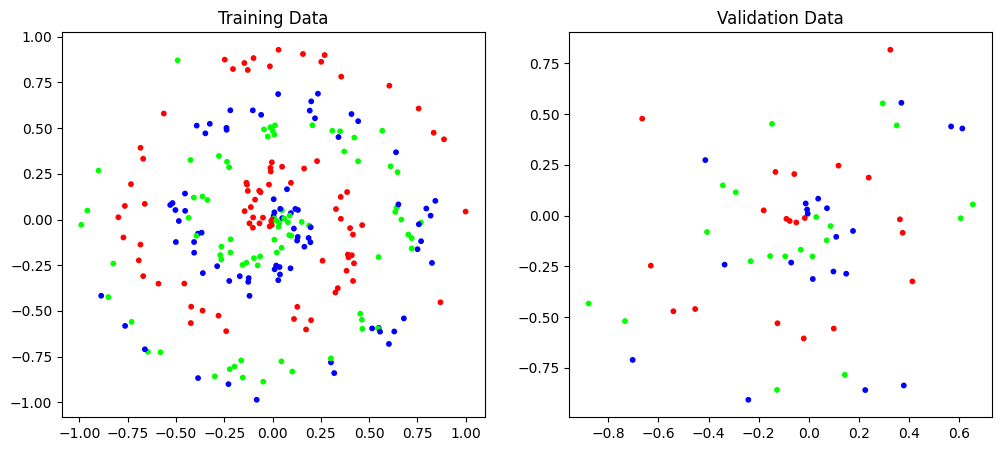

In [5]:
# ---------------------
# Create Data
# ---------------------
X, y = spiral_data(samples=100, classes=3)  # 300 total points
# X, y = vertical_data(samples=100, classes=4)

# Ensure even split per class (randomized)
train_ratio = 0.8
X_train, y_train, X_val, y_val = [], [], [], []

for class_index in np.unique(y):
    # Get all samples of this class
    X_class = X[y == class_index]
    y_class = y[y == class_index]

    # Randomly shuffle indices within this class
    indices = np.random.permutation(len(X_class))
    split_idx = int(len(X_class) * train_ratio)
    train_idx, val_idx = indices[:split_idx], indices[split_idx:]

    # Split class data using random indices
    X_train.append(X_class[train_idx])
    y_train.append(y_class[train_idx])
    X_val.append(X_class[val_idx])
    y_val.append(y_class[val_idx])

# Combine all classes back into single arrays
X_train = np.vstack(X_train)
y_train = np.hstack(y_train)
X_val = np.vstack(X_val)
y_val = np.hstack(y_val)

# Optional: shuffle full training and validation sets
train_shuffle = np.random.permutation(len(X_train))
val_shuffle = np.random.permutation(len(X_val))

X_train, y_train = X_train[train_shuffle], y_train[train_shuffle]
X_val, y_val = X_val[val_shuffle], y_val[val_shuffle]

# Diagnostics
print("Training shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Class balance (train):", np.bincount(y_train.astype(int)))
print("Class balance (val):", np.bincount(y_val.astype(int)))


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='brg', s=10)
plt.title("Training Data")
plt.subplot(1, 2, 2)
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap='brg', s=10)
plt.title("Validation Data")
plt.show()



Training shape: (240, 2) (240,)
Validation shape: (60, 2) (60,)
Class balance (train): [80 80 80]
Class balance (val): [20 20 20]
epoch     0 | train_loss: 1.099 | val_loss: 1.099 | train_acc: 34.17% | val_acc: 30.00% | lr: 1.0000
epoch   500 | train_loss: 0.859 | val_loss: 1.147 | train_acc: 55.42% | val_acc: 48.33% | lr: 0.6667
epoch  1000 | train_loss: 0.636 | val_loss: 1.181 | train_acc: 69.17% | val_acc: 50.00% | lr: 0.5000
epoch  1500 | train_loss: 0.578 | val_loss: 1.286 | train_acc: 76.25% | val_acc: 55.00% | lr: 0.4000
epoch  2000 | train_loss: 0.569 | val_loss: 1.370 | train_acc: 75.83% | val_acc: 56.67% | lr: 0.3333
epoch  2500 | train_loss: 0.572 | val_loss: 1.410 | train_acc: 74.58% | val_acc: 55.00% | lr: 0.2857
epoch  3000 | train_loss: 0.569 | val_loss: 1.459 | train_acc: 75.00% | val_acc: 56.67% | lr: 0.2500
epoch  3500 | train_loss: 0.570 | val_loss: 1.489 | train_acc: 73.75% | val_acc: 56.67% | lr: 0.2222
epoch  4000 | train_loss: 0.566 | val_loss: 1.498 | train_acc:

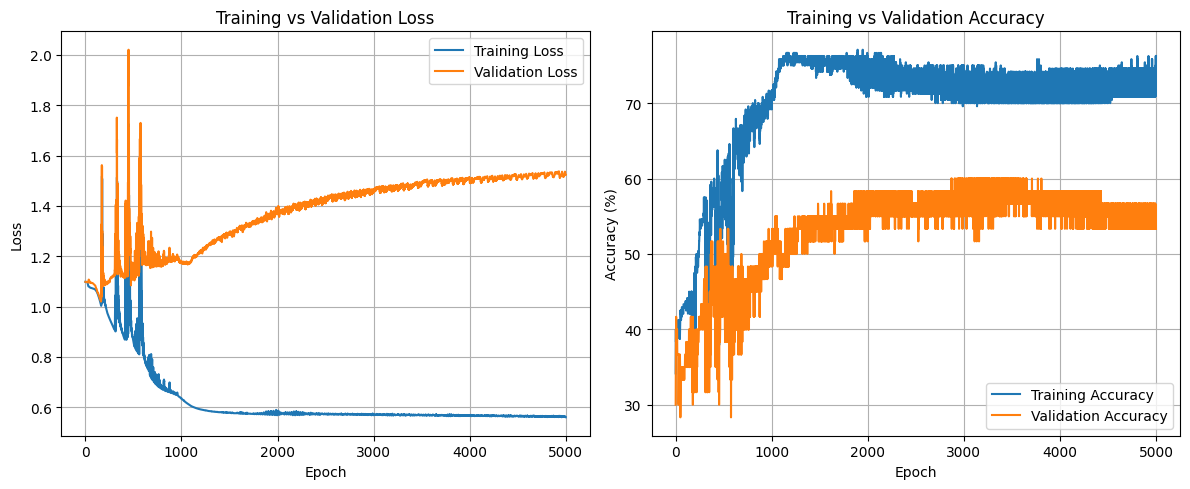

In [8]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data, vertical_data
import matplotlib.pyplot as plt

nnfs.init()

# ---------------------
# Layers and Functions
# ---------------------

class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases
    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0

class Activation_Softmax:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True)

class Loss:
    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        return np.mean(sample_losses)

class Loss_CategoricalCrossentropy(Loss):
    def forward(self, y_pred, y_true):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples), y_true]
        else:
            correct_confidences = np.sum(y_pred_clipped * y_true, axis=1)
        return -np.log(correct_confidences)
    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        labels = len(dvalues[0])
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
        self.dinputs = -y_true / dvalues
        self.dinputs = self.dinputs / samples

class Activation_Softmax_Loss_CategoricalCrossentropy:
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossentropy()
    def forward(self, inputs, y_true):
        self.activation.forward(inputs)
        self.output = self.activation.output
        return self.loss.calculate(self.output, y_true)
    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
        self.dinputs = dvalues.copy()
        self.dinputs[range(samples), y_true] -= 1
        self.dinputs = self.dinputs / samples

class Optimizer_SGD:
    def __init__(self, learning_rate=1., decay=0., momentum=0.):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.momentum = momentum
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (
                1. / (1. + self.decay * self.iterations))
    def update_params(self, layer):
        if self.momentum:
            if not hasattr(layer, "weight_momentums"):
                layer.weight_momentums = np.zeros_like(layer.weights)
                layer.bias_momentums = np.zeros_like(layer.biases)
            weight_updates = (
                self.momentum * layer.weight_momentums
                - self.current_learning_rate * layer.dweights)
            layer.weight_momentums = weight_updates
            bias_updates = (
                self.momentum * layer.bias_momentums
                - self.current_learning_rate * layer.dbiases)
            layer.bias_momentums = bias_updates
        else:
            weight_updates = -self.current_learning_rate * layer.dweights
            bias_updates = -self.current_learning_rate * layer.dbiases
        layer.weights += weight_updates
        layer.biases += bias_updates
    def post_update_params(self):
        self.iterations += 1

# ---------------------
# Create Data
# ---------------------
X, y = spiral_data(samples=100, classes=3)  # 300 total points
# X, y = vertical_data(samples=100, classes=4)

# Ensure even split per class (randomized)
train_ratio = 0.8
X_train, y_train, X_val, y_val = [], [], [], []

for class_index in np.unique(y):
    # Get all samples of this class
    X_class = X[y == class_index]
    y_class = y[y == class_index]

    # Randomly shuffle indices within this class
    indices = np.random.permutation(len(X_class))
    split_idx = int(len(X_class) * train_ratio)
    train_idx, val_idx = indices[:split_idx], indices[split_idx:]

    # Split class data using random indices
    X_train.append(X_class[train_idx])
    y_train.append(y_class[train_idx])
    X_val.append(X_class[val_idx])
    y_val.append(y_class[val_idx])

# Combine all classes back into single arrays
X_train = np.vstack(X_train)
y_train = np.hstack(y_train)
X_val = np.vstack(X_val)
y_val = np.hstack(y_val)

# Optional: shuffle full training and validation sets
train_shuffle = np.random.permutation(len(X_train))
val_shuffle = np.random.permutation(len(X_val))

X_train, y_train = X_train[train_shuffle], y_train[train_shuffle]
X_val, y_val = X_val[val_shuffle], y_val[val_shuffle]

# Diagnostics
print("Training shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Class balance (train):", np.bincount(y_train.astype(int)))
print("Class balance (val):", np.bincount(y_val.astype(int)))

# ---------------------
# Model Setup
# ---------------------
dense1 = Layer_Dense(2, 20)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(20, 3)

loss_activation_train = Activation_Softmax_Loss_CategoricalCrossentropy()
loss_activation_val = Activation_Softmax_Loss_CategoricalCrossentropy()

optimizer = Optimizer_SGD(learning_rate=1.0, decay=1e-3, momentum=0.9)

# ---------------------
# Training
# ---------------------
epochs = 5001
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # --- Training Forward ---
    dense1.forward(X_train)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss = loss_activation_train.forward(dense2.output, y_train)

    predictions = np.argmax(loss_activation_train.output, axis=1)
    acc = np.mean(predictions == y_train) * 100

    # --- Backward Pass ---
    loss_activation_train.backward(loss_activation_train.output, y_train)
    dense2.backward(loss_activation_train.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # --- Update Parameters ---
    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()

    # --- Validation Forward ---
    dense1.forward(X_val)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    val_loss = loss_activation_val.forward(dense2.output, y_val)
    val_predictions = np.argmax(loss_activation_val.output, axis=1)
    val_acc = np.mean(val_predictions == y_val) * 100

    # Record metrics
    train_losses.append(loss)
    val_losses.append(val_loss)
    train_accs.append(acc)
    val_accs.append(val_acc)

    # Print progress
    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:5d} | "
              f"train_loss: {loss:.3f} | val_loss: {val_loss:.3f} | "
              f"train_acc: {acc:.2f}% | val_acc: {val_acc:.2f}% | "
              f"lr: {optimizer.current_learning_rate:.4f}")

# ---------------------
# Plot Loss & Accuracy
# ---------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Loss curves
ax[0].plot(train_losses, label="Training Loss")
ax[0].plot(val_losses, label="Validation Loss")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy curves
ax[1].plot(train_accs, label="Training Accuracy")
ax[1].plot(val_accs, label="Validation Accuracy")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy (%)")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()


Now let's add dropout

Training shape: (240, 2) (240,)
Validation shape: (60, 2) (60,)
Class balance (train): [80 80 80]
Class balance (val): [20 20 20]
epoch     0 | train_loss: 1.099 | val_loss: 1.099 | train_acc: 40.42% | val_acc: 38.33% | lr: 1.0000
epoch   500 | train_loss: 0.928 | val_loss: 1.083 | train_acc: 57.92% | val_acc: 50.00% | lr: 0.6667
epoch  1000 | train_loss: 0.830 | val_loss: 1.004 | train_acc: 64.17% | val_acc: 50.00% | lr: 0.5000
epoch  1500 | train_loss: 0.695 | val_loss: 1.011 | train_acc: 67.50% | val_acc: 56.67% | lr: 0.4000
epoch  2000 | train_loss: 0.786 | val_loss: 0.997 | train_acc: 67.50% | val_acc: 60.00% | lr: 0.3333
epoch  2500 | train_loss: 0.702 | val_loss: 1.006 | train_acc: 70.83% | val_acc: 53.33% | lr: 0.2857
epoch  3000 | train_loss: 0.730 | val_loss: 0.966 | train_acc: 70.42% | val_acc: 56.67% | lr: 0.2500
epoch  3500 | train_loss: 0.798 | val_loss: 0.959 | train_acc: 67.92% | val_acc: 60.00% | lr: 0.2222
epoch  4000 | train_loss: 0.761 | val_loss: 1.007 | train_acc:

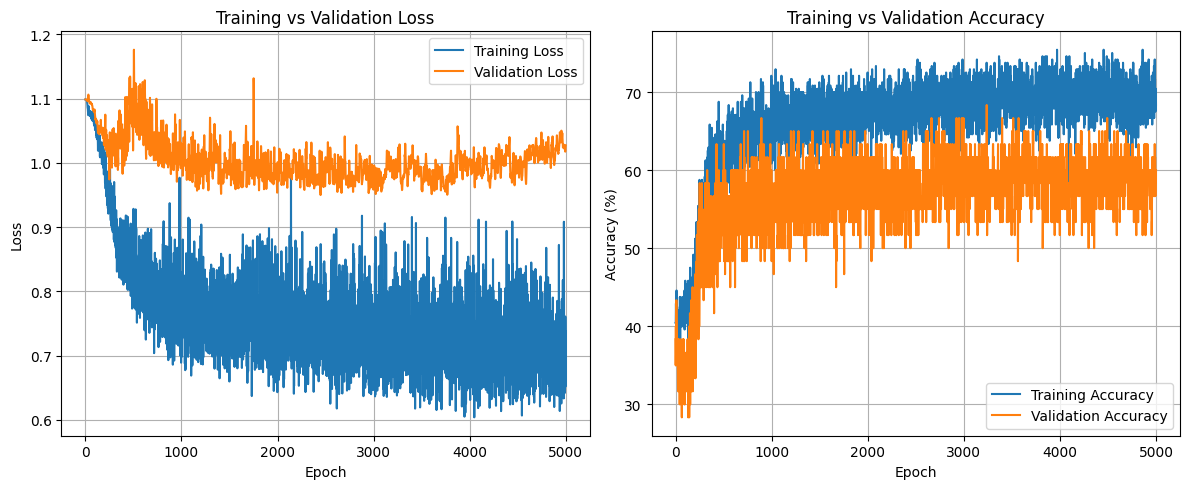

In [7]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt
from nnfs.datasets import vertical_data

nnfs.init()

# ---------------------
# Layers and Functions
# ---------------------

class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases
    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0

class Activation_Softmax:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True)

class Loss:
    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        return np.mean(sample_losses)

class Loss_CategoricalCrossentropy(Loss):
    def forward(self, y_pred, y_true):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples), y_true]
        else:
            correct_confidences = np.sum(y_pred_clipped * y_true, axis=1)
        return -np.log(correct_confidences)
    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        labels = len(dvalues[0])
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
        self.dinputs = -y_true / dvalues
        self.dinputs = self.dinputs / samples

class Activation_Softmax_Loss_CategoricalCrossentropy:
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossentropy()
    def forward(self, inputs, y_true):
        self.activation.forward(inputs)
        self.output = self.activation.output
        return self.loss.calculate(self.output, y_true)
    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
        self.dinputs = dvalues.copy()
        self.dinputs[range(samples), y_true] -= 1
        self.dinputs = self.dinputs / samples

class Optimizer_SGD:
    def __init__(self, learning_rate=1., decay=0., momentum=0.):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.momentum = momentum
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (
                1. / (1. + self.decay * self.iterations))
    def update_params(self, layer):
        if self.momentum:
            if not hasattr(layer, "weight_momentums"):
                layer.weight_momentums = np.zeros_like(layer.weights)
                layer.bias_momentums = np.zeros_like(layer.biases)
            weight_updates = (
                self.momentum * layer.weight_momentums
                - self.current_learning_rate * layer.dweights)
            layer.weight_momentums = weight_updates
            bias_updates = (
                self.momentum * layer.bias_momentums
                - self.current_learning_rate * layer.dbiases)
            layer.bias_momentums = bias_updates
        else:
            weight_updates = -self.current_learning_rate * layer.dweights
            bias_updates = -self.current_learning_rate * layer.dbiases
        layer.weights += weight_updates
        layer.biases += bias_updates
    def post_update_params(self):
        self.iterations += 1

class Layer_Dropout:
    def __init__(self, rate):
        self.rate = rate
    def forward(self, inputs, training):
        self.inputs = inputs
        if training:
            keep_prob = 1 - self.rate
            self.binary_mask = (np.random.rand(*inputs.shape) < keep_prob) / keep_prob
            self.output = inputs * self.binary_mask
        else:
            self.output = inputs.copy()
    def backward(self, dvalues):
        self.dinputs = dvalues * self.binary_mask
# ---------------------
# Create Data
# ---------------------
X, y = spiral_data(samples=100, classes=3)  # 300 total points
# X, y = vertical_data(samples=100, classes=4)

# Ensure even split per class (randomized)
train_ratio = 0.8
X_train, y_train, X_val, y_val = [], [], [], []

for class_index in np.unique(y):
    # Get all samples of this class
    X_class = X[y == class_index]
    y_class = y[y == class_index]

    # Randomly shuffle indices within this class
    indices = np.random.permutation(len(X_class))
    split_idx = int(len(X_class) * train_ratio)
    train_idx, val_idx = indices[:split_idx], indices[split_idx:]

    # Split class data using random indices
    X_train.append(X_class[train_idx])
    y_train.append(y_class[train_idx])
    X_val.append(X_class[val_idx])
    y_val.append(y_class[val_idx])

# Combine all classes back into single arrays
X_train = np.vstack(X_train)
y_train = np.hstack(y_train)
X_val = np.vstack(X_val)
y_val = np.hstack(y_val)

# Optional: shuffle full training and validation sets
train_shuffle = np.random.permutation(len(X_train))
val_shuffle = np.random.permutation(len(X_val))

X_train, y_train = X_train[train_shuffle], y_train[train_shuffle]
X_val, y_val = X_val[val_shuffle], y_val[val_shuffle]

# Diagnostics
print("Training shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Class balance (train):", np.bincount(y_train.astype(int)))
print("Class balance (val):", np.bincount(y_val.astype(int)))

# ---------------------
# Model Setup
# ---------------------
dense1 = Layer_Dense(2, 64)
activation1 = Activation_ReLU()
dropout1 = Layer_Dropout(rate=0.2)
dense2 = Layer_Dense(64, 3)

loss_activation_train = Activation_Softmax_Loss_CategoricalCrossentropy()
loss_activation_val = Activation_Softmax_Loss_CategoricalCrossentropy()

optimizer = Optimizer_SGD(learning_rate=1.0, decay=1e-3, momentum=0.9)

# ---------------------
# Training
# ---------------------
epochs = 5001
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # --- Training Forward ---
    dense1.forward(X_train)
    activation1.forward(dense1.output)
    dropout1.forward(activation1.output, training=True)
    dense2.forward(dropout1.output)
    loss = loss_activation_train.forward(dense2.output, y_train)

    predictions = np.argmax(loss_activation_train.output, axis=1)
    acc = np.mean(predictions == y_train) * 100

    # --- Backward Pass ---
    loss_activation_train.backward(loss_activation_train.output, y_train)
    dense2.backward(loss_activation_train.dinputs)
    dropout1.backward(dense2.dinputs)
    activation1.backward(dropout1.dinputs)
    dense1.backward(activation1.dinputs)

    # --- Update Parameters ---
    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()

    # --- Validation Forward ---
    dense1.forward(X_val)
    activation1.forward(dense1.output)
    dropout1.forward(activation1.output, training=False)
    dense2.forward(dropout1.output)
    val_loss = loss_activation_val.forward(dense2.output, y_val)
    val_predictions = np.argmax(loss_activation_val.output, axis=1)
    val_acc = np.mean(val_predictions == y_val) * 100

    # Record metrics
    train_losses.append(loss)
    val_losses.append(val_loss)
    train_accs.append(acc)
    val_accs.append(val_acc)

    # Print progress
    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:5d} | "
              f"train_loss: {loss:.3f} | val_loss: {val_loss:.3f} | "
              f"train_acc: {acc:.2f}% | val_acc: {val_acc:.2f}% | "
              f"lr: {optimizer.current_learning_rate:.4f}")

# ---------------------
# Plot Loss & Accuracy
# ---------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Loss curves
ax[0].plot(train_losses, label="Training Loss")
ax[0].plot(val_losses, label="Validation Loss")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy curves
ax[1].plot(train_accs, label="Training Accuracy")
ax[1].plot(val_accs, label="Validation Accuracy")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy (%)")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()


We can also increase parameters

Training shape: (240, 2) (240,)
Validation shape: (60, 2) (60,)
Class balance (train): [80 80 80]
Class balance (val): [20 20 20]
epoch     0 | train_loss: 1.099 | val_loss: 1.098 | train_acc: 29.58% | val_acc: 41.67% | lr: 1.0000
epoch   500 | train_loss: 0.633 | val_loss: 0.992 | train_acc: 71.25% | val_acc: 55.00% | lr: 0.6667
epoch  1000 | train_loss: 0.508 | val_loss: 0.884 | train_acc: 79.17% | val_acc: 75.00% | lr: 0.5000
epoch  1500 | train_loss: 0.504 | val_loss: 0.968 | train_acc: 82.08% | val_acc: 71.67% | lr: 0.4000
epoch  2000 | train_loss: 0.464 | val_loss: 0.910 | train_acc: 81.25% | val_acc: 71.67% | lr: 0.3333
epoch  2500 | train_loss: 0.464 | val_loss: 0.854 | train_acc: 82.92% | val_acc: 73.33% | lr: 0.2857
epoch  3000 | train_loss: 0.428 | val_loss: 0.912 | train_acc: 82.50% | val_acc: 71.67% | lr: 0.2500
epoch  3500 | train_loss: 0.456 | val_loss: 0.938 | train_acc: 81.67% | val_acc: 71.67% | lr: 0.2222
epoch  4000 | train_loss: 0.378 | val_loss: 0.900 | train_acc:

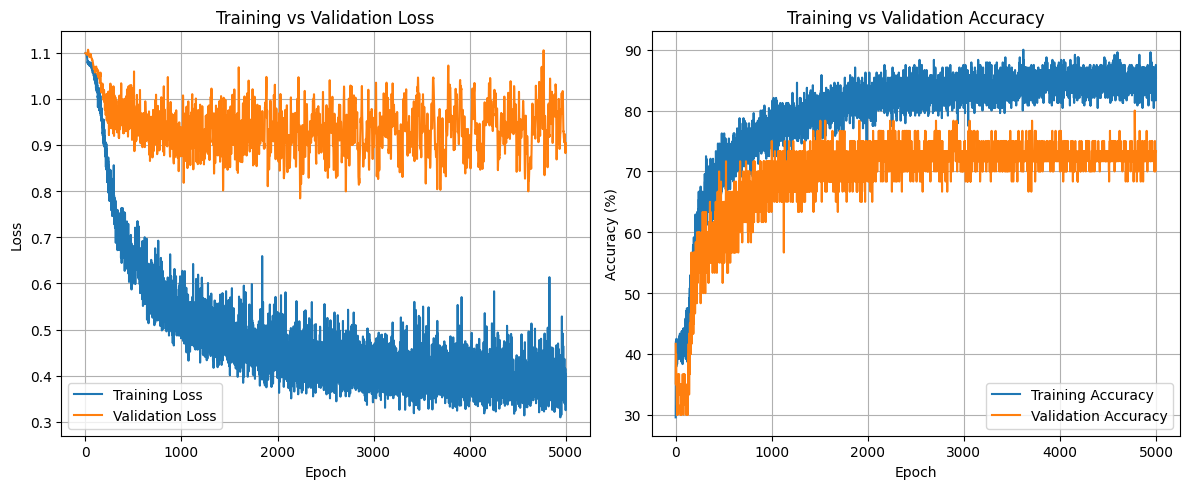

In [44]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt
from nnfs.datasets import vertical_data

nnfs.init()

# ---------------------
# Layers and Functions
# ---------------------

class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases
    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0

class Activation_Softmax:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True)

class Loss:
    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        return np.mean(sample_losses)

class Loss_CategoricalCrossentropy(Loss):
    def forward(self, y_pred, y_true):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples), y_true]
        else:
            correct_confidences = np.sum(y_pred_clipped * y_true, axis=1)
        return -np.log(correct_confidences)
    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        labels = len(dvalues[0])
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
        self.dinputs = -y_true / dvalues
        self.dinputs = self.dinputs / samples

class Activation_Softmax_Loss_CategoricalCrossentropy:
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossentropy()
    def forward(self, inputs, y_true):
        self.activation.forward(inputs)
        self.output = self.activation.output
        return self.loss.calculate(self.output, y_true)
    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
        self.dinputs = dvalues.copy()
        self.dinputs[range(samples), y_true] -= 1
        self.dinputs = self.dinputs / samples

class Optimizer_SGD:
    def __init__(self, learning_rate=1., decay=0., momentum=0.):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.momentum = momentum
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (
                1. / (1. + self.decay * self.iterations))
    def update_params(self, layer):
        if self.momentum:
            if not hasattr(layer, "weight_momentums"):
                layer.weight_momentums = np.zeros_like(layer.weights)
                layer.bias_momentums = np.zeros_like(layer.biases)
            weight_updates = (
                self.momentum * layer.weight_momentums
                - self.current_learning_rate * layer.dweights)
            layer.weight_momentums = weight_updates
            bias_updates = (
                self.momentum * layer.bias_momentums
                - self.current_learning_rate * layer.dbiases)
            layer.bias_momentums = bias_updates
        else:
            weight_updates = -self.current_learning_rate * layer.dweights
            bias_updates = -self.current_learning_rate * layer.dbiases
        layer.weights += weight_updates
        layer.biases += bias_updates
    def post_update_params(self):
        self.iterations += 1

class Layer_Dropout:
    def __init__(self, rate):
        self.rate = rate
    def forward(self, inputs, training):
        self.inputs = inputs
        if training:
            keep_prob = 1 - self.rate
            self.binary_mask = (np.random.rand(*inputs.shape) < keep_prob) / keep_prob
            self.output = inputs * self.binary_mask
        else:
            self.output = inputs.copy()
    def backward(self, dvalues):
        self.dinputs = dvalues * self.binary_mask

# ---------------------
# Create Data
# ---------------------
X, y = spiral_data(samples=100, classes=3)  # 300 total points
# X, y = vertical_data(samples=100, classes=4)

# Ensure even split per class (randomized)
train_ratio = 0.8
X_train, y_train, X_val, y_val = [], [], [], []

for class_index in np.unique(y):
    # Get all samples of this class
    X_class = X[y == class_index]
    y_class = y[y == class_index]

    # Randomly shuffle indices within this class
    indices = np.random.permutation(len(X_class))
    split_idx = int(len(X_class) * train_ratio)
    train_idx, val_idx = indices[:split_idx], indices[split_idx:]

    # Split class data using random indices
    X_train.append(X_class[train_idx])
    y_train.append(y_class[train_idx])
    X_val.append(X_class[val_idx])
    y_val.append(y_class[val_idx])

# Combine all classes back into single arrays
X_train = np.vstack(X_train)
y_train = np.hstack(y_train)
X_val = np.vstack(X_val)
y_val = np.hstack(y_val)

# Optional: shuffle full training and validation sets
train_shuffle = np.random.permutation(len(X_train))
val_shuffle = np.random.permutation(len(X_val))

X_train, y_train = X_train[train_shuffle], y_train[train_shuffle]
X_val, y_val = X_val[val_shuffle], y_val[val_shuffle]

# Diagnostics
print("Training shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Class balance (train):", np.bincount(y_train.astype(int)))
print("Class balance (val):", np.bincount(y_val.astype(int)))

# ---------------------
# Model Setup
# ---------------------
dense1 = Layer_Dense(2, 224)
activation1 = Activation_ReLU()
dropout1 = Layer_Dropout(rate=0.2)
dense2 = Layer_Dense(224, 3)

loss_activation_train = Activation_Softmax_Loss_CategoricalCrossentropy()
loss_activation_val = Activation_Softmax_Loss_CategoricalCrossentropy()

optimizer = Optimizer_SGD(learning_rate=1.0, decay=1e-3, momentum=0.9)

# ---------------------
# Training
# ---------------------
epochs = 5001
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # --- Training Forward ---
    dense1.forward(X_train)
    activation1.forward(dense1.output)
    dropout1.forward(activation1.output, training=True)
    dense2.forward(dropout1.output)
    loss = loss_activation_train.forward(dense2.output, y_train)

    predictions = np.argmax(loss_activation_train.output, axis=1)
    acc = np.mean(predictions == y_train) * 100

    # --- Backward Pass ---
    loss_activation_train.backward(loss_activation_train.output, y_train)
    dense2.backward(loss_activation_train.dinputs)
    dropout1.backward(dense2.dinputs)
    activation1.backward(dropout1.dinputs)
    dense1.backward(activation1.dinputs)

    # --- Update Parameters ---
    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()

    # --- Validation Forward ---
    dense1.forward(X_val)
    activation1.forward(dense1.output)
    dropout1.forward(activation1.output, training=False)
    dense2.forward(dropout1.output)
    val_loss = loss_activation_val.forward(dense2.output, y_val)
    val_predictions = np.argmax(loss_activation_val.output, axis=1)
    val_acc = np.mean(val_predictions == y_val) * 100

    # Record metrics
    train_losses.append(loss)
    val_losses.append(val_loss)
    train_accs.append(acc)
    val_accs.append(val_acc)

    # Print progress
    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:5d} | "
              f"train_loss: {loss:.3f} | val_loss: {val_loss:.3f} | "
              f"train_acc: {acc:.2f}% | val_acc: {val_acc:.2f}% | "
              f"lr: {optimizer.current_learning_rate:.4f}")

# ---------------------
# Plot Loss & Accuracy
# ---------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Loss curves
ax[0].plot(train_losses, label="Training Loss")
ax[0].plot(val_losses, label="Validation Loss")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy curves
ax[1].plot(train_accs, label="Training Accuracy")
ax[1].plot(val_accs, label="Validation Accuracy")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy (%)")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()


Or add another layer!

Training shape: (240, 2) (240,)
Validation shape: (60, 2) (60,)
Class balance (train): [80 80 80]
Class balance (val): [20 20 20]
epoch     0 | train_loss: 1.099 | val_loss: 1.099 | train_acc: 33.33% | val_acc: 36.67% | lr: 1.0000
epoch   500 | train_loss: 0.643 | val_loss: 1.039 | train_acc: 66.67% | val_acc: 50.00% | lr: 0.6667
epoch  1000 | train_loss: 0.395 | val_loss: 1.027 | train_acc: 76.25% | val_acc: 63.33% | lr: 0.5000
epoch  1500 | train_loss: 0.874 | val_loss: 1.178 | train_acc: 52.08% | val_acc: 40.00% | lr: 0.4000
epoch  2000 | train_loss: 0.865 | val_loss: 1.162 | train_acc: 53.33% | val_acc: 43.33% | lr: 0.3333
epoch  2500 | train_loss: 0.871 | val_loss: 1.215 | train_acc: 51.67% | val_acc: 41.67% | lr: 0.2857
epoch  3000 | train_loss: 0.861 | val_loss: 1.239 | train_acc: 52.50% | val_acc: 43.33% | lr: 0.2500
epoch  3500 | train_loss: 0.854 | val_loss: 1.325 | train_acc: 52.92% | val_acc: 41.67% | lr: 0.2222
epoch  4000 | train_loss: 0.814 | val_loss: 1.266 | train_acc:

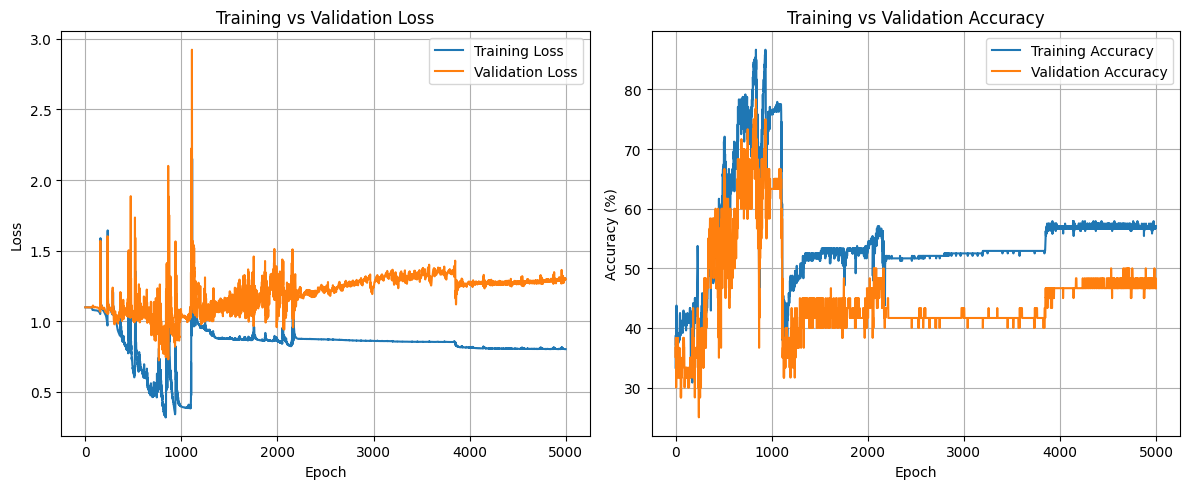

In [9]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt
from nnfs.datasets import vertical_data

nnfs.init()

# ---------------------
# Layers and Functions
# ---------------------

class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases
    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0

class Activation_Softmax:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True)

class Loss:
    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        return np.mean(sample_losses)

class Loss_CategoricalCrossentropy(Loss):
    def forward(self, y_pred, y_true):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples), y_true]
        else:
            correct_confidences = np.sum(y_pred_clipped * y_true, axis=1)
        return -np.log(correct_confidences)
    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        labels = len(dvalues[0])
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
        self.dinputs = -y_true / dvalues
        self.dinputs = self.dinputs / samples

class Activation_Softmax_Loss_CategoricalCrossentropy:
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossentropy()
    def forward(self, inputs, y_true):
        self.activation.forward(inputs)
        self.output = self.activation.output
        return self.loss.calculate(self.output, y_true)
    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
        self.dinputs = dvalues.copy()
        self.dinputs[range(samples), y_true] -= 1
        self.dinputs = self.dinputs / samples

class Optimizer_SGD:
    def __init__(self, learning_rate=1., decay=0., momentum=0.):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.momentum = momentum
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (
                1. / (1. + self.decay * self.iterations))
    def update_params(self, layer):
        if self.momentum:
            if not hasattr(layer, "weight_momentums"):
                layer.weight_momentums = np.zeros_like(layer.weights)
                layer.bias_momentums = np.zeros_like(layer.biases)
            weight_updates = (
                self.momentum * layer.weight_momentums
                - self.current_learning_rate * layer.dweights)
            layer.weight_momentums = weight_updates
            bias_updates = (
                self.momentum * layer.bias_momentums
                - self.current_learning_rate * layer.dbiases)
            layer.bias_momentums = bias_updates
        else:
            weight_updates = -self.current_learning_rate * layer.dweights
            bias_updates = -self.current_learning_rate * layer.dbiases
        layer.weights += weight_updates
        layer.biases += bias_updates
    def post_update_params(self):
        self.iterations += 1

# ---------------------
# Create Data
# ---------------------
X, y = spiral_data(samples=100, classes=3)  # 300 total points
# X, y = vertical_data(samples=100, classes=4)

# Ensure even split per class (randomized)
train_ratio = 0.8
X_train, y_train, X_val, y_val = [], [], [], []

for class_index in np.unique(y):
    # Get all samples of this class
    X_class = X[y == class_index]
    y_class = y[y == class_index]

    # Randomly shuffle indices within this class
    indices = np.random.permutation(len(X_class))
    split_idx = int(len(X_class) * train_ratio)
    train_idx, val_idx = indices[:split_idx], indices[split_idx:]

    # Split class data using random indices
    X_train.append(X_class[train_idx])
    y_train.append(y_class[train_idx])
    X_val.append(X_class[val_idx])
    y_val.append(y_class[val_idx])

# Combine all classes back into single arrays
X_train = np.vstack(X_train)
y_train = np.hstack(y_train)
X_val = np.vstack(X_val)
y_val = np.hstack(y_val)

# Optional: shuffle full training and validation sets
train_shuffle = np.random.permutation(len(X_train))
val_shuffle = np.random.permutation(len(X_val))

X_train, y_train = X_train[train_shuffle], y_train[train_shuffle]
X_val, y_val = X_val[val_shuffle], y_val[val_shuffle]

# Diagnostics
print("Training shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Class balance (train):", np.bincount(y_train.astype(int)))
print("Class balance (val):", np.bincount(y_val.astype(int)))


# ---------------------
# Model Setup (New 3-layer network)
# ---------------------
dense1 = Layer_Dense(2, 128)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(128, 64)
activation2 = Activation_ReLU()

dense3 = Layer_Dense(64, 3)  # Output layer

loss_activation_train = Activation_Softmax_Loss_CategoricalCrossentropy()
loss_activation_val = Activation_Softmax_Loss_CategoricalCrossentropy()

optimizer = Optimizer_SGD(learning_rate=1.0, decay=1e-3, momentum=0.9)

# ---------------------
# Training
# ---------------------
epochs = 5001
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # --- Forward (Training) ---
    dense1.forward(X_train)
    activation1.forward(dense1.output)

    dense2.forward(activation1.output)
    activation2.forward(dense2.output)

    dense3.forward(activation2.output)
    loss = loss_activation_train.forward(dense3.output, y_train)

    predictions = np.argmax(loss_activation_train.output, axis=1)
    acc = np.mean(predictions == y_train) * 100

    # --- Backward ---
    loss_activation_train.backward(loss_activation_train.output, y_train)
    dense3.backward(loss_activation_train.dinputs)
    activation2.backward(dense3.dinputs)
    dense2.backward(activation2.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # --- Update Parameters ---
    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.update_params(dense3)
    optimizer.post_update_params()

    # --- Validation ---
    dense1.forward(X_val)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)
    dense3.forward(activation2.output)
    val_loss = loss_activation_val.forward(dense3.output, y_val)
    val_predictions = np.argmax(loss_activation_val.output, axis=1)
    val_acc = np.mean(val_predictions == y_val) * 100

    # Record metrics
    train_losses.append(loss)
    val_losses.append(val_loss)
    train_accs.append(acc)
    val_accs.append(val_acc)

    # Print progress
    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:5d} | "
              f"train_loss: {loss:.3f} | val_loss: {val_loss:.3f} | "
              f"train_acc: {acc:.2f}% | val_acc: {val_acc:.2f}% | "
              f"lr: {optimizer.current_learning_rate:.4f}")

# ---------------------
# Plot Loss & Accuracy
# ---------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(train_losses, label="Training Loss")
ax[0].plot(val_losses, label="Validation Loss")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(train_accs, label="Training Accuracy")
ax[1].plot(val_accs, label="Validation Accuracy")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy (%)")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()
